<a href="https://colab.research.google.com/github/Blecyrajan/Dissertation/blob/main/BrainTumor_CNN_ViT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Downloading dataset




In [53]:
import kagglehub
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.


# 2. Install required libraries

In [54]:
!pip install torch torchvision opencv-python matplotlib tqdm scikit-learn

## 3. Import required libraries

In [55]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt


# 3. Dataset path






In [56]:
DATASET_PATH = "/kaggle/input/brain-tumor-mri-dataset"

In [57]:
os.listdir(DATASET_PATH)

['Training', 'Testing']

In [58]:
TRAIN_PATH = os.path.join(DATASET_PATH, "Training")
TEST_PATH  = os.path.join(DATASET_PATH, "Testing")

print("Train folders:", os.listdir(TRAIN_PATH))
print("Test folders:", os.listdir(TEST_PATH))

Train folders: ['pituitary', 'notumor', 'meningioma', 'glioma']
Test folders: ['pituitary', 'notumor', 'meningioma', 'glioma']


In [59]:
print("Dataset root:", os.listdir(DATASET_PATH))
print("\nTraining classes:", os.listdir(os.path.join(DATASET_PATH, "Training")))
print("\nTesting classes:", os.listdir(os.path.join(DATASET_PATH, "Testing")))


Dataset root: ['Training', 'Testing']

Training classes: ['pituitary', 'notumor', 'meningioma', 'glioma']

Testing classes: ['pituitary', 'notumor', 'meningioma', 'glioma']


# 4. Sample brain MRI

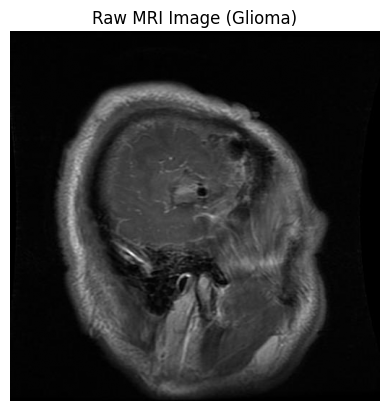

In [60]:
sample_class = "glioma"
sample_image = os.listdir(os.path.join(TRAIN_PATH, sample_class))[0]

img_path = os.path.join(TRAIN_PATH, sample_class, sample_image)
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray")
plt.title("Raw MRI Image (Glioma)")
plt.axis("off")
plt.show()


# DEFINE OUTPUT DIRECTORY

In [61]:
PROCESSED_ROOT = "/content/Processed_Dataset"

PROCESSED_TRAIN = os.path.join(PROCESSED_ROOT, "Training")
PROCESSED_TEST  = os.path.join(PROCESSED_ROOT, "Testing")

os.makedirs(PROCESSED_TRAIN, exist_ok=True)
os.makedirs(PROCESSED_TEST, exist_ok=True)

print("Processed folders created")


Processed folders created


# PROCESS & SAVE IMAGES

In [62]:
IMG_SIZE = 224
def preprocess_image(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) #resize to 224 x 224
    img = img / 255.0 #pixels are normalized

    # convert grayscale -> 3 channel
    img = np.stack([img, img, img], axis=-1)

    return img

In [63]:
def preprocess_and_save(input_root, output_root):
    classes = ["glioma", "meningioma", "pituitary", "notumor"]

    for cls in classes:
        input_cls_dir = os.path.join(input_root, cls)
        output_cls_dir = os.path.join(output_root, cls)

        os.makedirs(output_cls_dir, exist_ok=True)

        for img_name in os.listdir(input_cls_dir):
            img_path = os.path.join(input_cls_dir, img_name)

            img = preprocess_image(img_path)

            # convert back to uint8 for saving
            img_uint8 = (img * 255).astype(np.uint8)

            save_path = os.path.join(output_cls_dir, img_name)
            cv2.imwrite(save_path, img_uint8)

        print(f"Saved preprocessed images for class: {cls}")


# PREPROCESS & SAVE TRAINING DATA

In [64]:
preprocess_and_save(TRAIN_PATH, PROCESSED_TRAIN)

Saved preprocessed images for class: glioma
Saved preprocessed images for class: meningioma
Saved preprocessed images for class: pituitary
Saved preprocessed images for class: notumor


# PREPROCESS & SAVE TESTING DATA

In [65]:
preprocess_and_save(TEST_PATH, PROCESSED_TEST)

Saved preprocessed images for class: glioma
Saved preprocessed images for class: meningioma
Saved preprocessed images for class: pituitary
Saved preprocessed images for class: notumor


# VERIFY SAVED FILES

In [66]:
print("Processed Training folders:", os.listdir(PROCESSED_TRAIN))
print("Sample images in glioma:",
      os.listdir(os.path.join(PROCESSED_TRAIN, "glioma"))[:5])


Processed Training folders: ['pituitary', 'meningioma', 'glioma', 'notumor']
Sample images in glioma: ['Tr-gl_0654.jpg', 'Tr-gl_1180.jpg', 'Tr-gl_0196.jpg', 'Tr-gl_0682.jpg', 'Tr-gl_0225.jpg']


# VISUAL CHECK (RAW vs SAVED PROCESSED)

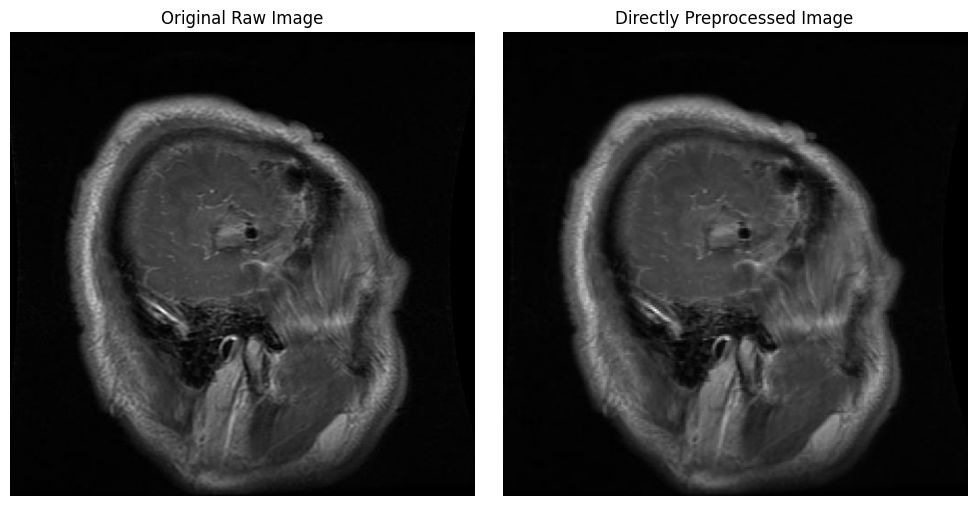

In [67]:
sample_class = "glioma"
sample_image_name = os.listdir(os.path.join(TRAIN_PATH, sample_class))[0]

# Get the full path for the raw image
raw_img_path = os.path.join(TRAIN_PATH, sample_class, sample_image_name)

# Load the raw image
raw_img = cv2.imread(raw_img_path, cv2.IMREAD_GRAYSCALE)

# Preprocess the *same* image using the defined function
# The preprocess_image function returns a normalized 3-channel image
processed_img_direct = preprocess_image(raw_img_path)

# For displaying with plt.imshow, if processed_img_direct is normalized (0-1),
# it will be displayed correctly. If we want to show it as grayscale uint8,
# we might need to convert it back to single channel and scale.
# However, imshow can handle float arrays directly.
# To show it as grayscale for direct comparison with `raw_img` (which is 1 channel gray),
# we can take one channel from the 3-channel processed image and scale it back to 0-255 for clarity if needed.
# Or, as preprocess_image outputs normalized float, imshow will handle it fine.

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original Raw Image")
plt.imshow(raw_img, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Directly Preprocessed Image")
# Displaying one channel of the 3-channel normalized image, scaled back to 0-255 if desired.
# Or directly display the normalized float array, matplotlib handles it.
plt.imshow(processed_img_direct[:,:,0], cmap="gray") # Taking one channel for grayscale display
plt.axis("off")

plt.tight_layout()
plt.show()

# UPDATE DATASET CLASS TO USE PROCESSED DATA

In [68]:
class MRIDataset(Dataset):
    def __init__(self, root_dir):
        self.samples = []
        self.class_map = {
            "glioma": 0,
            "meningioma": 1,
            "pituitary": 2,
            "notumor": 3
        }

        for cls in self.class_map:
            cls_dir = os.path.join(root_dir, cls)
            for img_name in os.listdir(cls_dir):
                self.samples.append(
                    (os.path.join(cls_dir, img_name), self.class_map[cls])
                )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        img = cv2.imread(img_path)
        img = img / 255.0
        img = torch.tensor(img).permute(2, 0, 1).float()

        return img, label


In [69]:
train_dataset = MRIDataset(PROCESSED_TRAIN)
test_dataset  = MRIDataset(PROCESSED_TEST)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False)

print("Train batches ready:", len(train_loader))


Train batches ready: 714


# PHASE 2 — CNN–ViT MODEL

# Confirm GPU

In [70]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cuda


# CNN feature extractor

In [71]:
class CNNEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU()
        )

    def forward(self, x):
        x = self.layer1(x)   # (B, 32, 112, 112)
        x = self.layer2(x)   # (B, 64, 56, 56)
        x = self.layer3(x)   # (B, 128, 56, 56)
        return x


In [72]:
cnn = CNNEncoder().to(device)

images, _ = next(iter(train_loader))
images = images.to(device)

cnn_features = cnn(images)
print("CNN output shape:", cnn_features.shape)


CNN output shape: torch.Size([8, 128, 56, 56])


# Patch embedding (CNN-ViT bridge)

In [73]:
class PatchEmbedding(nn.Module):
    def __init__(self):
        super().__init__()
        self.projection = nn.Conv2d(
            in_channels=128,
            out_channels=256,
            kernel_size=4,
            stride=4
        )

    def forward(self, x):
        x = self.projection(x)   # (B, 256, 14, 14)
        x = x.flatten(2)         # (B, 256, 196)
        x = x.transpose(1, 2)    # (B, 196, 256)
        return x


In [74]:
patch = PatchEmbedding().to(device)

tokens = patch(cnn_features)
print("Patch tokens shape:", tokens.shape)


Patch tokens shape: torch.Size([8, 196, 256])


# Vision Transformer Encoder

In [75]:
class ViTEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=256,
            nhead=8,
            dim_feedforward=512,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=4
        )

    def forward(self, x):
        return self.encoder(x)


In [76]:
vit = ViTEncoder().to(device)

vit_out = vit(tokens)
print("ViT output shape:", vit_out.shape)


ViT output shape: torch.Size([8, 196, 256])


# CNN-ViT

In [77]:
class CNN_ViT(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.cnn = CNNEncoder()
        self.patch = PatchEmbedding()
        self.vit = ViTEncoder()
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        cnn_features = self.cnn(x)
        tokens = self.patch(cnn_features)
        vit_out = self.vit(tokens)

        pooled = vit_out.mean(dim=1)
        logits = self.classifier(pooled)

        return logits, cnn_features


In [78]:
model = CNN_ViT().to(device)

logits, features = model(images)

print("Logits shape:", logits.shape)
print("CNN feature shape:", features.shape)


Logits shape: torch.Size([8, 4])
CNN feature shape: torch.Size([8, 128, 56, 56])


# PHASE 3 — EXPLAINABILITY

In [79]:
# Make sure gradients are enabled
torch.set_grad_enabled(True)


torch.autograd.grad_mode.set_grad_enabled(mode=True)

# GENERATE EXPLANATION MAPS

In [80]:
def generate_explanation_map(cnn_features, logits):
    """
    cnn_features: (B, C, H, W)
    logits: (B, num_classes)
    """

    preds = logits.argmax(dim=1)
    B, C, H, W = cnn_features.shape

    explanation_maps = []

    for i in range(B):
        # Take the score of the predicted class
        score = logits[i, preds[i]]

        # Compute gradients w.r.t CNN features
        # Removed create_graph=True to avoid RuntimeError with TransformerEncoderLayer's second-order gradients
        grads = torch.autograd.grad(
            score,
            cnn_features,
            retain_graph=True,
            create_graph=False # Changed to False
        )[0][i]

        # Channel importance
        weights = grads.mean(dim=(1, 2))  # (C,)

        # Weighted sum of feature maps
        cam = torch.sum(weights[:, None, None] * cnn_features[i], dim=0)

        cam = torch.relu(cam)

        # Normalize to [0, 1]
        cam = (cam - cam.min()) / (cam.max() + 1e-8)

        explanation_maps.append(cam)

    return torch.stack(explanation_maps)  # (B, H, W)


# TEST EXPLANATION MAP GENERATION

In [81]:
model.eval()

images, labels = next(iter(train_loader))
images = images.to(device)

logits, cnn_features = model(images)

exp_maps = generate_explanation_map(cnn_features, logits)

print("Explanation map shape:", exp_maps.shape)


Explanation map shape: torch.Size([8, 56, 56])


# VISUALIZE EXPLANATION MAP

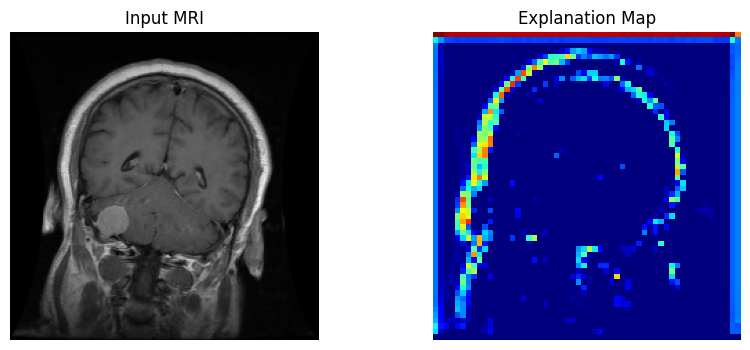

In [82]:
plt.figure(figsize=(10,4))

# Original image
plt.subplot(1,2,1)
plt.imshow(images[0].cpu().permute(1,2,0)[:,:,0], cmap="gray")
plt.title("Input MRI")
plt.axis("off")

# Explanation heatmap
plt.subplot(1,2,2)
plt.imshow(exp_maps[0].detach().cpu(), cmap="jet")
plt.title("Explanation Map")
plt.axis("off")

plt.show()


# EXPLAINABILITY CONSISTENCY LOSS

In [83]:
def explainability_consistency_loss(exp_maps, labels):
    """
    exp_maps: (B, H, W)
    labels: (B,)
    """

    loss = 0.0
    count = 0

    for i in range(len(exp_maps)):
        for j in range(i + 1, len(exp_maps)):
            if labels[i] == labels[j]:
                loss += F.mse_loss(exp_maps[i], exp_maps[j])
                count += 1

    return loss / (count + 1e-8)


# TEST CONSISTENCY LOSS

In [84]:
cons_loss = explainability_consistency_loss(exp_maps, labels)
print("Explainability consistency loss:", cons_loss.item())


Explainability consistency loss: 0.015940716490149498


# PHASE 4 — TRAINING THE MODEL

# SET TRAINING PARAMETERS

In [85]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 10        # keep small for first run
LAMBDA = 0.3       # weight for explainability loss

train_losses = []
val_losses = []

# BASIC TRAINING LOOP

In [87]:
from tqdm import tqdm
import torch.autograd

# Disable ALL optimized scaled dot product attention kernels for higher-order gradients
torch.backends.cuda.flash_sdp_enabled = False
torch.backends.cuda.mem_efficient_sdp_enabled = False
torch.backends.cuda.math_sdp_enabled = False # Explicitly disable math SDP too

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Training Epoch {epoch+1}"):
        images = images.to(device)
        labels = labels.to(device)
        images.requires_grad_(True) # Ensure gradients are tracked for input images

        optimizer.zero_grad()

        # Forward pass
        logits, cnn_features = model(images)

        # Classification loss
        cls_loss = criterion(logits, labels)

        # Explainability maps
        exp_maps = generate_explanation_map(cnn_features, logits)

        # Consistency loss
        exp_loss = explainability_consistency_loss(exp_maps, labels)

        # Total loss
        loss = cls_loss + LAMBDA * exp_loss

        # Backpropagation
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation step
    model.eval()
    val_running_loss = 0.0
    for images, labels in tqdm(test_loader, desc=f"Validation Epoch {epoch+1}"):
        images = images.to(device)
        labels = labels.to(device)
        images.requires_grad_(True) # Ensure gradients are tracked for input images in validation as well

        with torch.enable_grad(): # Explicitly enable grad for the forward pass
            logits, cnn_features = model(images)

        cls_loss_val = criterion(logits, labels)

        # Explainability maps are needed to calculate exp_loss_val
        exp_maps_val = generate_explanation_map(cnn_features, logits)
        exp_loss_val = explainability_consistency_loss(exp_maps_val, labels)

        val_loss = cls_loss_val + LAMBDA * exp_loss_val
        val_running_loss += val_loss.item()

    avg_val_loss = val_running_loss / len(test_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

Validation Epoch 1: 100%|██████████| 164/164 [00:13<00:00, 11.72it/s]


Epoch [1/10] - Train Loss: 0.6061 - Val Loss: 0.6581


Validation Epoch 2: 100%|██████████| 164/164 [00:14<00:00, 11.68it/s]


Epoch [2/10] - Train Loss: 0.4728 - Val Loss: 0.6478


Validation Epoch 3: 100%|██████████| 164/164 [00:14<00:00, 11.65it/s]


...

Epoch [8/10] - Train Loss: 0.2212 - Val Loss: 0.3054


Validation Epoch 9: 100%|██████████| 164/164 [00:14<00:00, 11.62it/s]


Epoch [9/10] - Train Loss: 0.1990 - Val Loss: 0.3843


Validation Epoch 10: 100%|██████████| 164/164 [00:14<00:00, 11.61it/s]

Epoch [10/10] - Train Loss: 0.1898 - Val Loss: 0.3464


# SAVE THE TRAINED MODEL

In [89]:
torch.save(model.state_dict(), "cnn_vit_explainable.pth")
print("Model saved successfully")


Model saved successfully


# QUICK TEST ACCURACY

In [90]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits, _ = model(images)
        preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("Test Accuracy:", correct / total)


Test Accuracy: 0.8718535469107551


# VISUALIZE EXPLANATION AFTER TRAINING

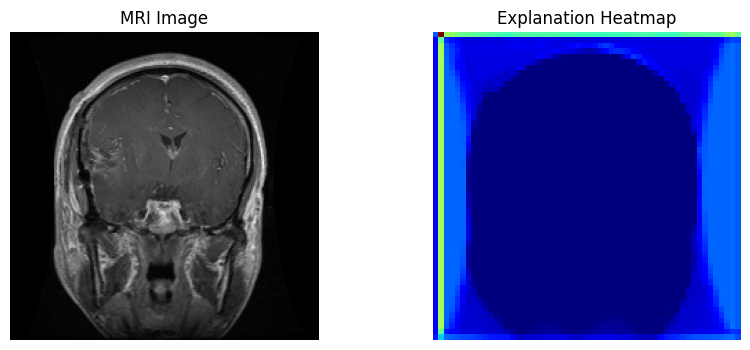

In [91]:
model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)

logits, cnn_features = model(images)
exp_maps = generate_explanation_map(cnn_features, logits)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(images[0].cpu().permute(1,2,0)[:,:,0], cmap="gray")
plt.title("MRI Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(exp_maps[0].detach().cpu(), cmap="jet")
plt.title("Explanation Heatmap")
plt.axis("off")

plt.show()


In [92]:
class_names = ["glioma", "meningioma", "pituitary", "notumor"]
print(class_names)


['glioma', 'meningioma', 'pituitary', 'notumor']


In [93]:
def preprocess_for_inference(img_path):
    """
    Uses the SAME preprocessing as training
    """
    img = preprocess_image(img_path)   # <-- reuse your function

    img_tensor = torch.tensor(img).permute(2, 0, 1).unsqueeze(0).float()
    return img_tensor


In [94]:
class_names = ["glioma", "meningioma", "pituitary", "notumor"]

def predict_mri(img_path, model, device):
    model.eval()

    img_tensor = preprocess_for_inference(img_path).to(device)

    with torch.no_grad():
        logits, _ = model(img_tensor)
        probs = torch.softmax(logits, dim=1)
        confidence, pred_idx = torch.max(probs, dim=1)

    return {
        "predicted_class": class_names[pred_idx.item()],
        "confidence": confidence.item()
    }


In [95]:
# Pick a RAW (unprocessed) image
true_class = "glioma"   # change to test other classes
img_name = os.listdir(os.path.join(TRAIN_PATH, true_class))[0]
img_path = os.path.join(TRAIN_PATH, true_class, img_name)

print("Input image:", img_path)

result = predict_mri(img_path, model, device)

print("Prediction:")
print("Predicted class:", result["predicted_class"])
print("Confidence:", round(result["confidence"], 4))


Input image: /kaggle/input/brain-tumor-mri-dataset/Training/glioma/Tr-gl_0954.jpg
Prediction:
Predicted class: glioma
Confidence: 0.8545


# Upload files

In [97]:
from google.colab import files

uploaded = files.upload()


Saving Te-noTr_0001.jpg to Te-noTr_0001.jpg


In [98]:
# Get uploaded filename
uploaded_filename = list(uploaded.keys())[0]
uploaded_img_path = "/content/" + uploaded_filename

print("Uploaded image path:", uploaded_img_path)


Uploaded image path: /content/Te-noTr_0001.jpg


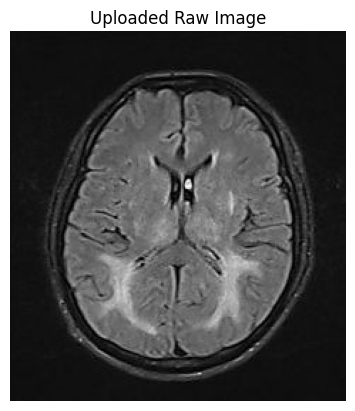

In [99]:
raw_img = cv2.imread(uploaded_img_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(raw_img, cmap="gray")
plt.title("Uploaded Raw Image")
plt.axis("off")
plt.show()


In [100]:
result = predict_mri(uploaded_img_path, model, device)

print("Prediction Result")
print("Predicted class:", result["predicted_class"])
print("Confidence:", round(result["confidence"], 4))


Prediction Result
Predicted class: notumor
Confidence: 0.9929


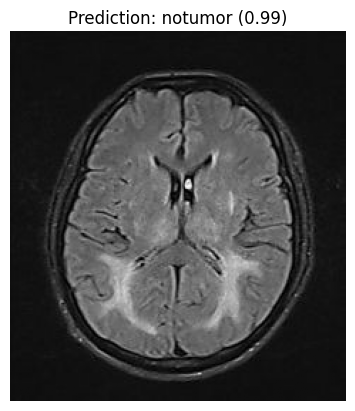

In [101]:
plt.imshow(raw_img, cmap="gray")
plt.title(
    f"Prediction: {result['predicted_class']} "
    f"({result['confidence']:.2f})"
)
plt.axis("off")
plt.show()


# Phase 5: Evaluation

# COLLECT PREDICTIONS FROM TEST SET

In [102]:
import numpy as np
from tqdm import tqdm

model.eval()

y_true = []
y_pred = []
y_probs = []

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.to(device)
        labels = labels.to(device)

        logits, _ = model(images)
        probs = torch.softmax(logits, dim=1)

        preds = torch.argmax(probs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

print("Collected predictions:", y_true.shape, y_pred.shape)


100%|██████████| 164/164 [00:02<00:00, 56.63it/s]

Collected predictions: (1311,) (1311,)


# CLASSIFICATION METRICS

In [103]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Overall Accuracy:", accuracy_score(y_true, y_pred))

print("\nMacro Precision:", precision_score(y_true, y_pred, average="macro"))
print("Macro Recall:", recall_score(y_true, y_pred, average="macro"))
print("Macro F1:", f1_score(y_true, y_pred, average="macro"))

print("\nDetailed Classification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))


Overall Accuracy: 0.8718535469107551

Macro Precision: 0.8789732262015957
Macro Recall: 0.8613997821350763
Macro F1: 0.8585198074299211

Detailed Classification Report:

              precision    recall  f1-score   support

      glioma     0.9635    0.6167    0.7520       300
  meningioma     0.7263    0.8497    0.7831       306
   pituitary     0.8757    0.9867    0.9279       300
     notumor     0.9504    0.9926    0.9710       405

    accuracy                         0.8719      1311
   macro avg     0.8790    0.8614    0.8585      1311
weighted avg     0.8840    0.8719    0.8672      1311



# CONFUSION MATRIX

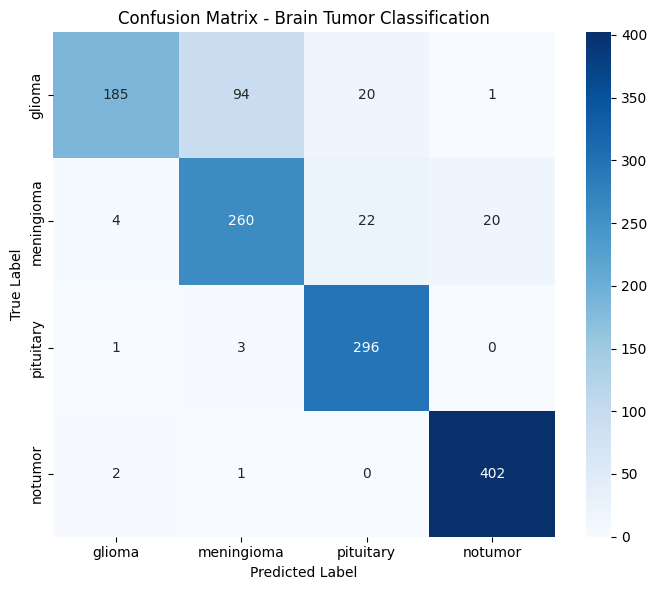

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Brain Tumor Classification")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()


# TRAINING vs VALIDATION LOSS CURVE

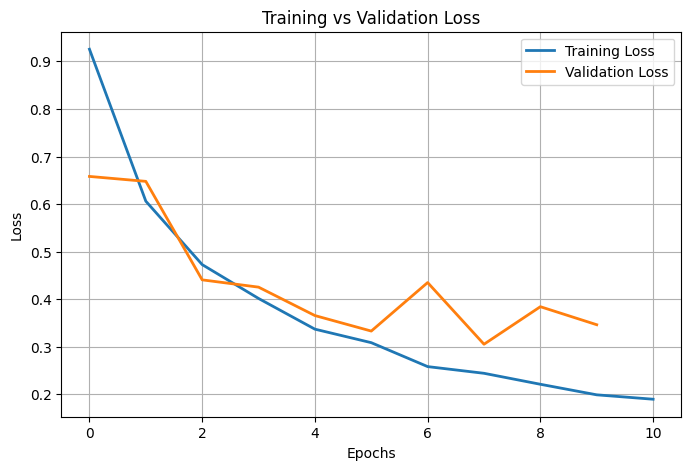

In [105]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss", linewidth=2)
plt.plot(val_losses, label="Validation Loss", linewidth=2)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.savefig("loss_curve.png", dpi=300)
plt.show()


# PER-CLASS PRECISION / RECALL / F1 BAR CHART

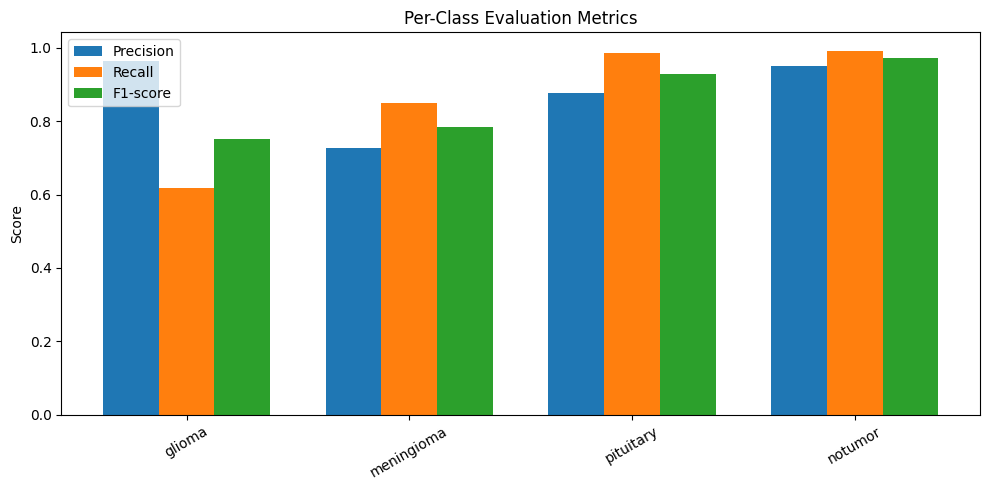

In [106]:
from sklearn.metrics import precision_recall_fscore_support
import numpy as np

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average=None
)

x = np.arange(len(class_names))
width = 0.25

plt.figure(figsize=(10,5))

plt.bar(x - width, precision, width, label="Precision")
plt.bar(x, recall, width, label="Recall")
plt.bar(x + width, f1, width, label="F1-score")

plt.xticks(x, class_names, rotation=30)
plt.ylabel("Score")
plt.title("Per-Class Evaluation Metrics")

plt.legend()
plt.tight_layout()
plt.savefig("per_class_metrics.png", dpi=300)
plt.show()


# ROC CURVES (MULTI-CLASS)

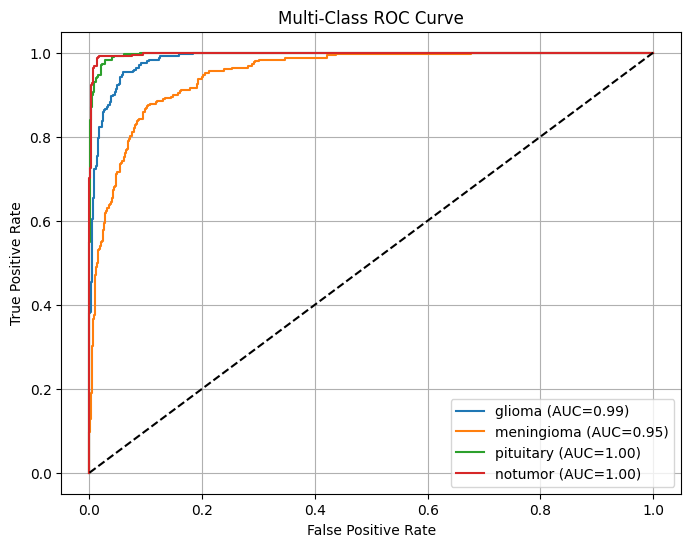

In [107]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_true_bin = label_binarize(y_true, classes=range(len(class_names)))

plt.figure(figsize=(8,6))

for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend()
plt.grid(True)

plt.savefig("roc_curve.png", dpi=300)
plt.show()


# TRAINING vs VALIDATION ACCURACY CURVE

In [110]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label="Training Accuracy", linewidth=2)
plt.plot(val_accuracies, label="Validation Accuracy", linewidth=2)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.savefig("accuracy_curve.png", dpi=300)
plt.show()


NameError: name 'train_accuracies' is not defined

<Figure size 800x500 with 0 Axes>

In [111]:
from google.colab import files

files.download("confusion_matrix.png")
files.download("loss_curve.png")
#files.download("accuracy_curve.png")
files.download("per_class_metrics.png")
files.download("roc_curve.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>